# Моделирование

In [1]:
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from catboost import CatBoostClassifier, Pool

SEED = 42

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

df = pd.read_excel("FINAL_pregnancy.xlsx")

TARGET = "pregnancy"
DROP_TARGETS = ["pregnancy", "delivery"]


X = df.drop(columns=DROP_TARGETS, errors="ignore")
y = df[TARGET].astype(int)

print("Rows:", len(df))
print("Target balance:\n", y.value_counts().to_dict())
print("Features:", X.shape[1])


Rows: 131
Target balance:
 {1: 116, 0: 15}
Features: 30


In [2]:
class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, min_freq: int = 5):
        self.min_freq = min_freq

    def fit(self, X, y=None):
        X = X.copy()
        self.object_cols_ = [c for c in X.columns if X[c].dtype == "object"]
        self.keep_values_ = {}

        for col in self.object_cols_:
            vc = X[col].fillna("Missing").astype(str).value_counts()
            self.keep_values_[col] = set(vc[vc >= self.min_freq].index.tolist())

        return self

    def transform(self, X):
        X = X.copy()
        for col in self.object_cols_:
            vals = X[col].fillna("Missing").astype(str)
            X[col] = vals.where(vals.isin(self.keep_values_[col]), "Other")
        return X


In [3]:
def pick_best_threshold(y_true, probs, metric="f1"):
    best_thr = 0.5
    best_score = -1.0

    for thr in np.arange(0.05, 0.96, 0.01):
        pred = (probs >= thr).astype(int)

        if metric == "f1":
            score = f1_score(y_true, pred, zero_division=0)
        elif metric == "recall":
            score = recall_score(y_true, pred, zero_division=0)
        elif metric == "youden":
            # Recall  + Specificity - 1
            # Максимум при балансе обоих классов — защищено от тривиального решения
            sens = recall_score(y_true, pred, zero_division=0)
            spec = recall_score(1 - y_true, 1 - pred, zero_division=0)
            score = sens + spec - 1.0
        elif metric == "balanced_f1":
            # Macro F1 — среднее F1 по обоим классам
            score = f1_score(y_true, pred, average='macro', zero_division=0)
        else:
            raise ValueError("metric must be 'f1', 'recall', 'youden', or 'balanced_f1'")

        if score > best_score:
            best_score = score
            best_thr = float(thr)

    return best_thr, float(best_score)

In [4]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=SEED, stratify=y_train_full
)

In [5]:
print("=== РАЗМЕРЫ ВЫБОРОК ===")
print(f"Train       : {X_train.shape[0]}")
print(f"Validation  : {X_val.shape[0]}")
print(f"Test        : {X_test.shape[0]}")
print(f"Всего       : {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]}")

=== РАЗМЕРЫ ВЫБОРОК ===
Train       : 78
Validation  : 26
Test        : 27
Всего       : 131


In [6]:
rare_grouper = RareCategoryGrouper(min_freq=5).fit(X_train)

X_train_rg = rare_grouper.transform(X_train)
X_val_rg   = rare_grouper.transform(X_val)
X_test_rg  = rare_grouper.transform(X_test)

numeric_features = X_train_rg.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train_rg.select_dtypes(include=["object"]).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features),
    ]
)

### Logistic Regression

In [7]:
def run_lr_cv(X, y, preprocessor, rare_grouper, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    
    f1_list, auc_list, acc_list, prec_list, rec_list = [], [], [], [], []
    thr_list = []
    
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"\n=== Fold {fold+1}/{n_splits} ===")
        
        X_tr_raw = X.iloc[tr_idx].copy()
        X_val_raw = X.iloc[val_idx].copy()
        y_tr = y.iloc[tr_idx].copy()
        y_val = y.iloc[val_idx].copy()
        
        fold_grouper = RareCategoryGrouper(min_freq=5).fit(X_tr_raw)

        X_tr  = fold_grouper.transform(X_tr_raw)
        X_val = fold_grouper.transform(X_val_raw)
        
        X_tr_p = preprocessor.fit_transform(X_tr)
        X_val_p = preprocessor.transform(X_val)
        
        model = LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=SEED,
        )
        model.fit(X_tr_p, y_tr)
        
        val_prob = model.predict_proba(X_val_p)[:, 1]
        
        best_thr, _ = pick_best_threshold(y_val.values, val_prob,  metric="youden")
        val_pred = (val_prob >= best_thr).astype(int)
        thr_list.append(best_thr)
        
        f1 = f1_score(y_val, val_pred)
        auc = roc_auc_score(y_val, val_prob)
        acc = accuracy_score(y_val, val_pred)
        prec = precision_score(y_val, val_pred, zero_division=0)
        rec = recall_score(y_val, val_pred, zero_division=0)
        
        f1_list.append(f1)
        auc_list.append(auc)
        acc_list.append(acc)
        prec_list.append(prec)
        rec_list.append(rec)
        
        print(f"Fold {fold+1}: F1={f1:.4f} | AUC={auc:.4f} | Acc={acc:.4f} | Thr={best_thr:.2f}")
    
    print("\n" + "="*55)
    print("Logistic Regression 5-Fold CV Results")
    print("="*55)
    print(f"F1-score:  {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
    print(f"AUC-ROC:   {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")
    print(f"Accuracy:  {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
    print(f"Precision: {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
    print(f"Recall:    {np.mean(rec_list):.4f} ± {np.std(rec_list):.4f}")
    
    return {
        'f1_mean': np.mean(f1_list), 'f1_std': np.std(f1_list),
        'auc_mean': np.mean(auc_list), 'auc_std': np.std(auc_list),
        'acc_mean': np.mean(acc_list), 'acc_std': np.std(acc_list),
        'prec_mean': np.mean(prec_list), 'prec_std': np.std(prec_list),
        'rec_mean': np.mean(rec_list), 'rec_std': np.std(rec_list),
        'cv_threshold': float(np.median(thr_list))
    }


print("\n=== 5-FOLD STRATIFIED CV (Logistic Regression) ===")
lr_cv = run_lr_cv(X_train_full, y_train_full, preprocessor, rare_grouper, n_splits=5)


=== 5-FOLD STRATIFIED CV (Logistic Regression) ===

=== Fold 1/5 ===
Fold 1: F1=0.9474 | AUC=0.7632 | Acc=0.9048 | Thr=0.15

=== Fold 2/5 ===
Fold 2: F1=0.9444 | AUC=0.8947 | Acc=0.9048 | Thr=0.29

=== Fold 3/5 ===
Fold 3: F1=0.9444 | AUC=0.8148 | Acc=0.9048 | Thr=0.20

=== Fold 4/5 ===
Fold 4: F1=0.8889 | AUC=0.6481 | Acc=0.8095 | Thr=0.55

=== Fold 5/5 ===
Fold 5: F1=0.9444 | AUC=0.7778 | Acc=0.9000 | Thr=0.05

Logistic Regression 5-Fold CV Results
F1-score:  0.9339 ± 0.0225
AUC-ROC:   0.7797 ± 0.0801
Accuracy:  0.8848 ± 0.0377
Precision: 0.9450 ± 0.0352
Recall:    0.9240 ± 0.0263


### Random Forest

In [8]:
def run_rf_cv(X, y, preprocessor, rare_grouper, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    
    f1_list, auc_list, acc_list, prec_list, rec_list = [], [], [], [], []
    thr_list = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"\n=== Fold {fold+1}/{n_splits} ===")
        
        X_tr_raw = X.iloc[tr_idx].copy()
        X_val_raw = X.iloc[val_idx].copy()
        y_tr = y.iloc[tr_idx].copy()
        y_val = y.iloc[val_idx].copy()
        
        fold_grouper = RareCategoryGrouper(min_freq=5).fit(X_tr_raw)

        X_tr  = fold_grouper.transform(X_tr_raw)
        X_val = fold_grouper.transform(X_val_raw)
        
        X_tr_p = preprocessor.fit_transform(X_tr)
        X_val_p = preprocessor.transform(X_val)
        
        model = RandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            min_samples_split=5,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1
        )
        model.fit(X_tr_p, y_tr)
        
        val_prob = model.predict_proba(X_val_p)[:, 1]
        
        best_thr, _ = pick_best_threshold(y_val.values, val_prob,  metric="youden")
        val_pred = (val_prob >= best_thr).astype(int)
        thr_list.append(best_thr)
        
        f1 = f1_score(y_val, val_pred)
        auc = roc_auc_score(y_val, val_prob)
        acc = accuracy_score(y_val, val_pred)
        prec = precision_score(y_val, val_pred, zero_division=0)
        rec = recall_score(y_val, val_pred, zero_division=0)
        
        f1_list.append(f1)
        auc_list.append(auc)
        acc_list.append(acc)
        prec_list.append(prec)
        rec_list.append(rec)
        
        print(f"Fold {fold+1}: F1={f1:.4f} | AUC={auc:.4f} | Acc={acc:.4f} | Thr={best_thr:.2f}")
    
    print("\n" + "="*55)
    print("Random Forest 5-Fold CV Results")
    print("="*55)
    print(f"F1-score:  {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
    print(f"AUC-ROC:   {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")
    print(f"Accuracy:  {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
    print(f"Precision: {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
    print(f"Recall:    {np.mean(rec_list):.4f} ± {np.std(rec_list):.4f}")
    
    return {
        'f1_mean': np.mean(f1_list), 'f1_std': np.std(f1_list),
        'auc_mean': np.mean(auc_list), 'auc_std': np.std(auc_list),
        'acc_mean': np.mean(acc_list), 'acc_std': np.std(acc_list),
        'prec_mean': np.mean(prec_list), 'prec_std': np.std(prec_list),
        'rec_mean': np.mean(rec_list), 'rec_std': np.std(rec_list),
        'cv_threshold': float(np.median(thr_list))
    }


print("\n=== 5-FOLD STRATIFIED CV (Random Forest) ===")
rf_cv = run_rf_cv(X_train_full, y_train_full, preprocessor, rare_grouper, n_splits=5)


=== 5-FOLD STRATIFIED CV (Random Forest) ===

=== Fold 1/5 ===
Fold 1: F1=0.8485 | AUC=0.7895 | Acc=0.7619 | Thr=0.86

=== Fold 2/5 ===
Fold 2: F1=0.9143 | AUC=0.8947 | Acc=0.8571 | Thr=0.69

=== Fold 3/5 ===
Fold 3: F1=0.8000 | AUC=0.8519 | Acc=0.7143 | Thr=0.87

=== Fold 4/5 ===
Fold 4: F1=0.8000 | AUC=0.8519 | Acc=0.7143 | Thr=0.78

=== Fold 5/5 ===
Fold 5: F1=0.8387 | AUC=0.7500 | Acc=0.7500 | Thr=0.80

Random Forest 5-Fold CV Results
F1-score:  0.8403 ± 0.0419
AUC-ROC:   0.8276 ± 0.0513
Accuracy:  0.7595 ± 0.0524
Precision: 1.0000 ± 0.0000
Recall:    0.7269 ± 0.0643


### CatBoost

In [9]:
cat_cols = categorical_features

def run_cb_cv(X, y, rare_grouper, cat_cols, n_splits=5):

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    f1_list, auc_list, acc_list, prec_list, rec_list = [], [], [], [], []
    thr_list = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"\n=== Fold {fold+1}/{n_splits} ===")

        X_tr_raw = X.iloc[tr_idx].copy()
        X_val_raw = X.iloc[val_idx].copy()

        fold_grouper = RareCategoryGrouper(min_freq=5).fit(X_tr_raw)

        X_tr  = fold_grouper.transform(X_tr_raw)
        X_val = fold_grouper.transform(X_val_raw)
        y_tr  = y.iloc[tr_idx]
        y_val = y.iloc[val_idx]

        for col in cat_cols:
            X_tr[col]  = X_tr[col].fillna("Missing").astype(str)
            X_val[col] = X_val[col].fillna("Missing").astype(str)

        tr_pool  = Pool(X_tr,  y_tr,  cat_features=cat_cols)
        val_pool = Pool(X_val, y_val, cat_features=cat_cols)

        fold_model = CatBoostClassifier(
            iterations=3000,
            learning_rate=0.03,
            depth=4,
            l2_leaf_reg=5.0,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=SEED,
            verbose=False,
            auto_class_weights="Balanced",
            od_type="Iter",
            od_wait=150,
        )

        fold_model.fit(tr_pool, eval_set=val_pool, use_best_model=True)

        val_prob = fold_model.predict_proba(val_pool)[:, 1]

        best_thr, _ = pick_best_threshold(y_val.values, val_prob, metric="youden")
        val_pred = (val_prob >= best_thr).astype(int)
        thr_list.append(best_thr)

        f1_list.append(f1_score(y_val, val_pred))
        auc_list.append(roc_auc_score(y_val, val_prob))
        acc_list.append(accuracy_score(y_val, val_pred))
        prec_list.append(precision_score(y_val, val_pred, zero_division=0))
        rec_list.append(recall_score(y_val, val_pred, zero_division=0))

        print(f"Fold {fold+1}: F1={f1_list[-1]:.4f} | AUC={auc_list[-1]:.4f} | Thr={best_thr:.2f}")

    cv_threshold = float(np.median(thr_list))  # медиана устойчивее к выбросам
    print(f"CV threshold (median): {cv_threshold:.4f}  | folds: {[round(t,2) for t in thr_list]}")


    print("\n" + "="*55)
    print("CatBoost 5-Fold CV Results (mean ± std)")
    print("="*55)
    print(f"F1-score:  {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
    print(f"AUC-ROC:   {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")
    print(f"Accuracy:  {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
    print(f"Precision: {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
    print(f"Recall:    {np.mean(rec_list):.4f} ± {np.std(rec_list):.4f}")

    return {
        'f1_mean': np.mean(f1_list),   'f1_std': np.std(f1_list),
        'auc_mean': np.mean(auc_list), 'auc_std': np.std(auc_list),
        'acc_mean': np.mean(acc_list), 'acc_std': np.std(acc_list),
        'prec_mean': np.mean(prec_list),'prec_std': np.std(prec_list),
        'rec_mean': np.mean(rec_list), 'rec_std': np.std(rec_list),
        'cv_threshold': cv_threshold,
    }

cb_cv = run_cb_cv(X_train_full, y_train_full, rare_grouper, cat_cols)


=== Fold 1/5 ===
Fold 1: F1=1.0000 | AUC=1.0000 | Thr=0.49

=== Fold 2/5 ===
Fold 2: F1=0.9444 | AUC=0.9737 | Thr=0.43

=== Fold 3/5 ===
Fold 3: F1=0.9412 | AUC=0.9630 | Thr=0.50

=== Fold 4/5 ===
Fold 4: F1=0.8000 | AUC=0.8889 | Thr=0.48

=== Fold 5/5 ===
Fold 5: F1=0.9714 | AUC=0.9583 | Thr=0.49
CV threshold (median): 0.4900  | folds: [0.49, 0.43, 0.5, 0.48, 0.49]

CatBoost 5-Fold CV Results (mean ± std)
F1-score:  0.9314 ± 0.0691
AUC-ROC:   0.9568 ± 0.0369
Accuracy:  0.8948 ± 0.0968
Precision: 1.0000 ± 0.0000
Recall:    0.8789 ± 0.1135


### MLP

In [10]:
class MLP(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)


def train_mlp(X_train, y_train, X_val, y_val, threshold_metric="youden"):
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
    y_val_np  = y_val.values

    model = MLP(input_dim=X_train_t.shape[1])

    pos_count = y_train_t.sum().item()
    neg_count = len(y_train_t) - pos_count
    pos_weight = torch.tensor([neg_count / max(pos_count, 1)], dtype=torch.float32)
    
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=10
    )

    val_f1_history = []
    val_auc_history = []
    best_val_f1 = -1.0
    best_state = None
    best_epoch = 0
    patience = 40
    counter = 0

    for epoch in range(400):
        model.train()
        optimizer.zero_grad()

        logits = model(X_train_t)
        loss = criterion(logits, y_train_t)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_prob = torch.sigmoid(model(X_val_t)).cpu().numpy().ravel()

        _, val_f1 = pick_best_threshold(y_val_np, val_prob, metric=threshold_metric)
        val_auc = roc_auc_score(y_val_np, val_prob)

        val_f1_history.append(val_f1)
        val_auc_history.append(val_auc)

        scheduler.step(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        val_prob = torch.sigmoid(model(X_val_t)).cpu().numpy().ravel()

    best_thr, _ = pick_best_threshold(y_val_np, val_prob,  metric=threshold_metric)

    return model, best_thr, best_epoch, val_f1_history, val_auc_history

In [11]:
def run_mlp_cv(X, y, preprocessor, rare_grouper, n_splits=5, threshold_metric="youden"):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    
    f1_list, auc_list, acc_list, prec_list, rec_list = [], [], [], [], []
    all_histories = []

    thr_list = []
    epoch_list = []
    
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"\n=== Fold {fold+1}/{n_splits} ===")
        
        X_tr_raw = X.iloc[tr_idx].copy()
        X_val_raw = X.iloc[val_idx].copy()
        y_tr = y.iloc[tr_idx].copy()
        y_val = y.iloc[val_idx].copy()

        fold_grouper = RareCategoryGrouper(min_freq=5).fit(X_tr_raw)

        X_tr  = fold_grouper.transform(X_tr_raw)
        X_val = fold_grouper.transform(X_val_raw)
        
        X_tr_proc = preprocessor.fit_transform(X_tr)  
        X_val_proc = preprocessor.transform(X_val)   

        model, best_thr, best_epoch, val_f1_hist, val_auc_hist = train_mlp(
            X_tr_proc, y_tr, X_val_proc, y_val, threshold_metric=threshold_metric
        )
        thr_list.append(best_thr)
        epoch_list.append(best_epoch)
        
        all_histories.append({
            'fold': fold+1,
            'f1_hist': val_f1_hist,
            'auc_hist': val_auc_hist,
            'best_epoch': best_epoch,
            'best_thr': best_thr
        })

        model.eval()
        with torch.no_grad():
            val_logits = model(torch.tensor(X_val_proc, dtype=torch.float32))
            val_probs = torch.sigmoid(val_logits).numpy().flatten()
        
        val_pred = (val_probs >= best_thr).astype(int)
        
        f1 = f1_score(y_val, val_pred)
        auc = roc_auc_score(y_val, val_probs)
        acc = accuracy_score(y_val, val_pred)
        prec = precision_score(y_val, val_pred, zero_division=0)
        rec = recall_score(y_val, val_pred, zero_division=0)
        
        f1_list.append(f1)
        auc_list.append(auc)
        acc_list.append(acc)
        prec_list.append(prec)
        rec_list.append(rec)
        
        print(f"Fold {fold+1}: F1={f1:.4f} | AUC={auc:.4f} | Acc={acc:.4f} | Thr={best_thr:.2f}")
    
    print("\n" + "="*55)
    print("MLP 5-Fold CV Results (mean ± std)")
    print("="*55)
    print(f"F1-score:  {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
    print(f"AUC-ROC:   {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")
    print(f"Accuracy:  {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
    print(f"Precision: {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
    print(f"Recall:    {np.mean(rec_list):.4f} ± {np.std(rec_list):.4f}")
    
    return {
        'f1_mean': np.mean(f1_list), 'f1_std': np.std(f1_list),
        'auc_mean': np.mean(auc_list), 'auc_std': np.std(auc_list),
        'acc_mean': np.mean(acc_list), 'acc_std': np.std(acc_list),
        'prec_mean': np.mean(prec_list), 'prec_std': np.std(prec_list),
        'rec_mean': np.mean(rec_list), 'rec_std': np.std(rec_list),
        'histories': all_histories,
        'cv_threshold': float(np.median(thr_list)),
        'cv_best_epoch': int(np.median(epoch_list)),
    }

mlp_cv  = run_mlp_cv(
    X_train_full, y_train_full,
    preprocessor, rare_grouper,
    n_splits=5,
    threshold_metric="youden"
)


=== Fold 1/5 ===
Fold 1: F1=0.8824 | AUC=0.8947 | Acc=0.8095 | Thr=0.50

=== Fold 2/5 ===
Fold 2: F1=0.9444 | AUC=0.8947 | Acc=0.9048 | Thr=0.47

=== Fold 3/5 ===
Fold 3: F1=0.9444 | AUC=0.7963 | Acc=0.9048 | Thr=0.48

=== Fold 4/5 ===
Fold 4: F1=0.9444 | AUC=0.7222 | Acc=0.9048 | Thr=0.47

=== Fold 5/5 ===
Fold 5: F1=0.9730 | AUC=0.5278 | Acc=0.9500 | Thr=0.43

MLP 5-Fold CV Results (mean ± std)
F1-score:  0.9377 ± 0.0298
AUC-ROC:   0.7672 ± 0.1362
Accuracy:  0.8948 ± 0.0461
Precision: 0.9673 ± 0.0268
Recall:    0.9146 ± 0.0709


In [12]:
comparison_data = [
    {
        "Model": "Logistic Regression",
        "AUC-ROC": f"{lr_cv['auc_mean']:.4f} ± {lr_cv['auc_std']:.4f}",
        "F1-score": f"{lr_cv['f1_mean']:.4f} ± {lr_cv['f1_std']:.4f}",
        "Accuracy": f"{lr_cv['acc_mean']:.4f} ± {lr_cv['acc_std']:.4f}",
        "Precision": f"{lr_cv['prec_mean']:.4f} ± {lr_cv['prec_std']:.4f}",
        "Sensitivity": f"{lr_cv['rec_mean']:.4f} ± {lr_cv['rec_std']:.4f}",
    },
    {
        "Model": "Random Forest",
        "AUC-ROC": f"{rf_cv['auc_mean']:.4f} ± {rf_cv['auc_std']:.4f}",
        "F1-score": f"{rf_cv['f1_mean']:.4f} ± {rf_cv['f1_std']:.4f}",
        "Accuracy": f"{rf_cv['acc_mean']:.4f} ± {rf_cv['acc_std']:.4f}",
        "Precision": f"{rf_cv['prec_mean']:.4f} ± {rf_cv['prec_std']:.4f}",
        "Sensitivity": f"{rf_cv['rec_mean']:.4f} ± {rf_cv['rec_std']:.4f}",
    },
    {
        "Model": "CatBoost",
        "AUC-ROC": f"{cb_cv['auc_mean']:.4f} ± {cb_cv['auc_std']:.4f}",
        "F1-score": f"{cb_cv['f1_mean']:.4f} ± {cb_cv['f1_std']:.4f}",
        "Accuracy": f"{cb_cv['acc_mean']:.4f} ± {cb_cv['acc_std']:.4f}",
        "Precision": f"{cb_cv['prec_mean']:.4f} ± {cb_cv['prec_std']:.4f}",
        "Sensitivity": f"{cb_cv['rec_mean']:.4f} ± {cb_cv['rec_std']:.4f}",
    },
    {
        "Model": "MLP (PyTorch)",
        "AUC-ROC": f"{mlp_cv ['auc_mean']:.4f} ± {mlp_cv ['auc_std']:.4f}",
        "F1-score": f"{mlp_cv ['f1_mean']:.4f} ± {mlp_cv ['f1_std']:.4f}",
        "Accuracy": f"{mlp_cv ['acc_mean']:.4f} ± {mlp_cv ['acc_std']:.4f}",
        "Precision": f"{mlp_cv ['prec_mean']:.4f} ± {mlp_cv ['prec_std']:.4f}",
        "Sensitivity": f"{mlp_cv ['rec_mean']:.4f} ± {mlp_cv ['rec_std']:.4f}",
    },
]

results_cv = pd.DataFrame(comparison_data).sort_values(
    by="AUC-ROC", ascending=False
).reset_index(drop=True)

print("\n" + "="*90)
print("СРАВНЕНИЕ МОДЕЛЕЙ (5-Fold Stratified Cross-Validation)")
print("="*90)
print(results_cv.to_string(index=False))
print("="*90)

best_model = results_cv.loc[0, "Model"]
print(f"\nЛучшая модель по AUC-ROC: {best_model}")


СРАВНЕНИЕ МОДЕЛЕЙ (5-Fold Stratified Cross-Validation)
              Model         AUC-ROC        F1-score        Accuracy       Precision     Sensitivity
           CatBoost 0.9568 ± 0.0369 0.9314 ± 0.0691 0.8948 ± 0.0968 1.0000 ± 0.0000 0.8789 ± 0.1135
      Random Forest 0.8276 ± 0.0513 0.8403 ± 0.0419 0.7595 ± 0.0524 1.0000 ± 0.0000 0.7269 ± 0.0643
Logistic Regression 0.7797 ± 0.0801 0.9339 ± 0.0225 0.8848 ± 0.0377 0.9450 ± 0.0352 0.9240 ± 0.0263
      MLP (PyTorch) 0.7672 ± 0.1362 0.9377 ± 0.0298 0.8948 ± 0.0461 0.9673 ± 0.0268 0.9146 ± 0.0709

Лучшая модель по AUC-ROC: CatBoost


# Финальное обучение MLP

In [13]:
def calculate_clinical_metrics(y_true, y_pred, y_prob=None):

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0     
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0      
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0      
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0            
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    metrics = {
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'Accuracy': round(accuracy, 4),
        'Sensitivity': round(recall, 4),
        'Specificity': round(specificity, 4),
        'Precision': round(precision, 4),
        'NPV': round(npv, 4),
        'F1-score': round(f1, 4)
    }
    
    if y_prob is not None:
        metrics['AUC-ROC'] = round(roc_auc_score(y_true, y_prob), 4)
    
    return cm, metrics

In [14]:
seeds = [42, 123, 456, 789, 1011, 2023, 777]   
results = []

print("=== Запуск финальной MLP с разными seeds ===\n")

def train_mlp_final(X_train, y_train, n_epochs):
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)

    model = MLP(input_dim=X_train_t.shape[1])
    pos_count = y_train_t.sum().item()
    neg_count = len(y_train_t) - pos_count
    pos_weight = torch.tensor([neg_count / max(pos_count, 1)], dtype=torch.float32)
    
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

    for epoch in range(n_epochs): 
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train_t), y_train_t)
        loss.backward()
        optimizer.step()

    model.eval()
    return model

X_train_val_rg = rare_grouper.transform(pd.concat([X_train, X_val]))
X_test_rg      = rare_grouper.transform(X_test)

X_train_val_p  = preprocessor.fit_transform(X_train_val_rg)
X_test_p       = preprocessor.transform(X_test_rg) 

best_thr = mlp_cv['cv_threshold'] 

for seed in seeds:
    set_seed(seed)

    final_mlp = train_mlp_final(
        X_train_val_p,
        pd.concat([y_train, y_val]),
        n_epochs=mlp_cv['cv_best_epoch']
    )

    best_thr = mlp_cv['cv_threshold']

    final_mlp.eval()
    with torch.no_grad():
        y_prob = torch.sigmoid(
            final_mlp(torch.tensor(X_test_p, dtype=torch.float32))
        ).numpy().flatten()

    y_pred = (y_prob >= best_thr).astype(int)
    
    cm, metrics = calculate_clinical_metrics(y_test, y_pred, y_prob)
    
    metrics['AUC-ROC'] = round(roc_auc_score(y_test, y_prob), 4)
    metrics['Threshold'] = round(best_thr, 4)
    metrics['Seed'] = seed
    
    results.append(metrics)
    
    print(f"Seed {seed}: F1={metrics['F1-score']:.4f} | AUC={metrics['AUC-ROC']:.4f} | Thr={best_thr:.2f}")


df_mlp = pd.DataFrame(results)
df_mlp.to_excel('MLP_results_seeds.xlsx', index=False)

print("\n" + "="*70)
print("MLP — Финальная оценка на Test (mean ± std)")
print("="*70)

summary = {
    'Accuracy':    f"{df_mlp['Accuracy'].mean():.4f} ± {df_mlp['Accuracy'].std():.4f}",
    'Sensitivity': f"{df_mlp['Sensitivity'].mean():.4f} ± {df_mlp['Sensitivity'].std():.4f}",
    'Specificity': f"{df_mlp['Specificity'].mean():.4f} ± {df_mlp['Specificity'].std():.4f}",
    'Precision': f"{df_mlp['Precision'].mean():.4f} ± {df_mlp['Precision'].std():.4f}",
    'NPV': f"{df_mlp['NPV'].mean():.4f} ± {df_mlp['NPV'].std():.4f}",
    'F1-score':    f"{df_mlp['F1-score'].mean():.4f} ± {df_mlp['F1-score'].std():.4f}",
    'AUC-ROC':     f"{df_mlp['AUC-ROC'].mean():.4f} ± {df_mlp['AUC-ROC'].std():.4f}",
}

for metric, value in summary.items():
    print(f"{metric:15}: {value}")

print("\nСредний выбранный порог:", round(df_mlp['Threshold'].mean(), 4))

=== Запуск финальной MLP с разными seeds ===

Seed 42: F1=0.9167 | AUC=0.6250 | Thr=0.47
Seed 123: F1=0.9200 | AUC=0.5556 | Thr=0.47
Seed 456: F1=0.2222 | AUC=0.5417 | Thr=0.47
Seed 789: F1=0.9412 | AUC=0.4583 | Thr=0.47
Seed 1011: F1=0.8980 | AUC=0.4167 | Thr=0.47
Seed 2023: F1=0.9200 | AUC=0.5556 | Thr=0.47
Seed 777: F1=0.0000 | AUC=0.6389 | Thr=0.47

MLP — Финальная оценка на Test (mean ± std)
Accuracy       : 0.6561 ± 0.3366
Sensitivity    : 0.6964 ± 0.4355
Specificity    : 0.3333 ± 0.4714
Precision      : 0.7793 ± 0.3462
NPV            : 0.0813 ± 0.1243
F1-score       : 0.6883 ± 0.3997
AUC-ROC        : 0.5417 ± 0.0810

Средний выбранный порог: 0.47


### ФИНАЛЬНАЯ ОЦЕНКА МОДЕЛЕЙ (на Train + Val → Test)

In [15]:
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

X_train_val_rg = rare_grouper.transform(X_train_val)
X_test_rg      = rare_grouper.transform(X_test)
X_train_val_p  = preprocessor.fit_transform(X_train_val_rg)
X_test_p       = preprocessor.transform(X_test_rg)

X_train_val_cat = rare_grouper.transform(X_train_val)
X_val_cat       = rare_grouper.transform(X_val)
X_test_cat      = rare_grouper.transform(X_test)

for col in cat_cols:
    X_train_val_cat[col] = X_train_val_cat[col].astype(str)
    X_val_cat[col]       = X_val_cat[col].astype(str)
    X_test_cat[col]      = X_test_cat[col].astype(str)

print("=" * 70)
print("ФИНАЛЬНАЯ ОЦЕНКА BASELINE-МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("=" * 70)

final_results = []

# 1. Logistic Regression

logreg = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=SEED
)
logreg.fit(X_train_val_p, y_train_val)
best_thr_lr  = lr_cv['cv_threshold']

test_prob_lr = logreg.predict_proba(X_test_p)[:, 1]
test_pred_lr = (test_prob_lr >= best_thr_lr).astype(int)

_, metrics_lr = calculate_clinical_metrics(y_test, test_pred_lr, test_prob_lr)
metrics_lr['Model'] = 'Logistic Regression'
metrics_lr['Threshold'] = round(best_thr_lr, 4)
final_results.append(metrics_lr)

print(f"\nLogistic Regression | Threshold = {best_thr_lr:.4f}")
print(f"F1 = {metrics_lr['F1-score']:.4f} | AUC = {metrics_lr.get('AUC-ROC', 'N/A')}")

# 2. Random Forest

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_split=5,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)
rf.fit(X_train_val_p, y_train_val)
best_thr_rf  = rf_cv['cv_threshold']

test_prob_rf = rf.predict_proba(X_test_p)[:, 1]
test_pred_rf = (test_prob_rf >= best_thr_rf).astype(int)

_, metrics_rf = calculate_clinical_metrics(y_test, test_pred_rf, test_prob_rf)
metrics_rf['Model'] = 'Random Forest'
metrics_rf['Threshold'] = round(best_thr_rf, 4)
final_results.append(metrics_rf)

print(f"\nRandom Forest       | Threshold = {best_thr_rf:.4f}")
print(f"F1 = {metrics_rf['F1-score']:.4f} | AUC = {metrics_rf.get('AUC-ROC', 'N/A')}")

# 3. CatBoost

train_val_pool = Pool(X_train_val_cat, y_train_val, cat_features=cat_cols)
val_pool_final = Pool(X_val_cat,       y_val,       cat_features=cat_cols)
test_pool_final= Pool(X_test_cat,      y_test,      cat_features=cat_cols)

cat_model_final = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.03,
    depth=4,
    l2_leaf_reg=5.0,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=SEED,
    verbose=False,
    auto_class_weights="Balanced",
    od_type="Iter",
    od_wait=150,
)
cat_model_final.fit(train_val_pool, use_best_model=False)
best_thr_cat = cb_cv['cv_threshold']

test_prob_cat = cat_model_final.predict_proba(test_pool_final)[:, 1]
test_pred_cat = (test_prob_cat >= best_thr_cat).astype(int)

_, metrics_cat = calculate_clinical_metrics(y_test, test_pred_cat, test_prob_cat)
metrics_cat['Model'] = 'CatBoost'
metrics_cat['Threshold'] = round(best_thr_cat, 4)
final_results.append(metrics_cat)

print(f"\nCatBoost            | Threshold = {best_thr_cat:.4f}")
print(f"F1 = {metrics_cat['F1-score']:.4f} | AUC = {metrics_cat.get('AUC-ROC', 'N/A')}")

# Итоговая таблица

df_final = pd.DataFrame(final_results)
df_final = df_final[['Model', 'Threshold', 'Accuracy', 'Sensitivity', 
                     'Specificity', 'Precision', 'NPV', 'F1-score', 'AUC-ROC']]

print("\n" + "=" * 90)
print("ИТОГОВАЯ ТАБЛИЦА ФИНАЛЬНЫХ BASELINE-МОДЕЛЕЙ (на тестовой выборке)")
print("=" * 90)
print(df_final.to_string(index=False))

ФИНАЛЬНАЯ ОЦЕНКА BASELINE-МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ

Logistic Regression | Threshold = 0.2000
F1 = 0.8936 | AUC = 0.8056

Random Forest       | Threshold = 0.8000
F1 = 0.7907 | AUC = 0.7083

CatBoost            | Threshold = 0.4900
F1 = 0.8511 | AUC = 0.7222

ИТОГОВАЯ ТАБЛИЦА ФИНАЛЬНЫХ BASELINE-МОДЕЛЕЙ (на тестовой выборке)
              Model  Threshold  Accuracy  Sensitivity  Specificity  Precision   NPV  F1-score  AUC-ROC
Logistic Regression       0.20    0.8148       0.8750       0.3333     0.9130 0.250    0.8936   0.8056
      Random Forest       0.80    0.6667       0.7083       0.3333     0.8947 0.125    0.7907   0.7083
           CatBoost       0.49    0.7407       0.8333       0.0000     0.8696 0.000    0.8511   0.7222


In [16]:
results = [
    {
        'Model': 'Logistic Regression',
        'AUC-ROC': metrics_lr['AUC-ROC'],
        'Threshold': metrics_lr['Threshold'],
        'Accuracy': metrics_lr['Accuracy'],
        'Sensitivity': metrics_lr['Sensitivity'],
        'Specificity': metrics_lr['Specificity'],
        'Precision': metrics_lr['Precision'],
        'NPV': metrics_lr['NPV'],
        'F1-score': metrics_lr['F1-score'],
    },

    {
        'Model': 'Random Forest',
        'AUC-ROC': metrics_rf['AUC-ROC'],
        'Threshold': metrics_rf['Threshold'],
        'Accuracy': metrics_rf['Accuracy'],
        'Sensitivity': metrics_rf['Sensitivity'],
        'Specificity': metrics_rf['Specificity'],
        'Precision': metrics_rf['Precision'],
        'NPV': metrics_rf['NPV'],
        'F1-score': metrics_rf['F1-score'],
    },

    {
        'Model': 'CatBoost',
        'AUC-ROC': metrics_cat['AUC-ROC'],
        'Threshold': metrics_cat['Threshold'],
        'Accuracy': metrics_cat['Accuracy'],
        'Sensitivity': metrics_cat['Sensitivity'],
        'Specificity': metrics_cat['Specificity'],
        'Precision': metrics_cat['Precision'],
        'NPV': metrics_cat['NPV'],
        'F1-score': metrics_cat['F1-score'],
    }
]

df_final = pd.DataFrame(results)

mlp_row = {
    'Model': 'MLP (PyTorch)',
    'AUC-ROC':     f"{df_mlp['AUC-ROC'].mean():.4f} ± {df_mlp['AUC-ROC'].std():.4f}",
    'Threshold': round(df_mlp['Threshold'].mean(), 4),
    'Accuracy':    f"{df_mlp['Accuracy'].mean():.4f} ± {df_mlp['Accuracy'].std():.4f}",
    'Sensitivity': f"{df_mlp['Sensitivity'].mean():.4f} ± {df_mlp['Sensitivity'].std():.4f}",
    'Specificity': f"{df_mlp['Specificity'].mean():.4f} ± {df_mlp['Specificity'].std():.4f}",
    'Precision': f"{df_mlp['Precision'].mean():.4f} ± {df_mlp['Precision'].std():.4f}",
    'NPV': f"{df_mlp['NPV'].mean():.4f} ± {df_mlp['NPV'].std():.4f}",
    'F1-score':    f"{df_mlp['F1-score'].mean():.4f} ± {df_mlp['F1-score'].std():.4f}",
}

df_final = pd.concat([df_final, pd.DataFrame([mlp_row])], ignore_index=True)

def extract_auc(value):
    if isinstance(value, str):
        return float(value.split('±')[0].strip())
    else:
        return float(value)

df_final['auc_numeric'] = df_final['AUC-ROC'].apply(extract_auc)

df_final = df_final.sort_values(by='auc_numeric', ascending=False).reset_index(drop=True)

df_final = df_final.drop(columns=['auc_numeric'])

desired_order = [
    'Model', 'Threshold', 'AUC-ROC', 'Accuracy',
    'Sensitivity', 'Specificity',
    'Precision', 'NPV', 'F1-score'
]

df_final = df_final[desired_order]

print("\n" + "=" * 110)
print("ИТОГОВАЯ СРАВНИТЕЛЬНАЯ ТАБЛИЦА МОДЕЛЕЙ (Финальная оценка на тестовой выборке)")
print("=" * 110)
print(df_final.to_string(index=False))
print("=" * 110)


ИТОГОВАЯ СРАВНИТЕЛЬНАЯ ТАБЛИЦА МОДЕЛЕЙ (Финальная оценка на тестовой выборке)
              Model  Threshold         AUC-ROC        Accuracy     Sensitivity     Specificity       Precision             NPV        F1-score
Logistic Regression       0.20          0.8056          0.8148           0.875          0.3333           0.913            0.25          0.8936
           CatBoost       0.49          0.7222          0.7407          0.8333             0.0          0.8696             0.0          0.8511
      Random Forest       0.80          0.7083          0.6667          0.7083          0.3333          0.8947           0.125          0.7907
      MLP (PyTorch)       0.47 0.5417 ± 0.0810 0.6561 ± 0.3366 0.6964 ± 0.4355 0.3333 ± 0.4714 0.7793 ± 0.3462 0.0813 ± 0.1243 0.6883 ± 0.3997


# SHAP

### CatBoost

C:\Users\alisa\AppData\Local\Temp\ipykernel_17948\3276492366.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_rg, plot_type="bar", show=False)


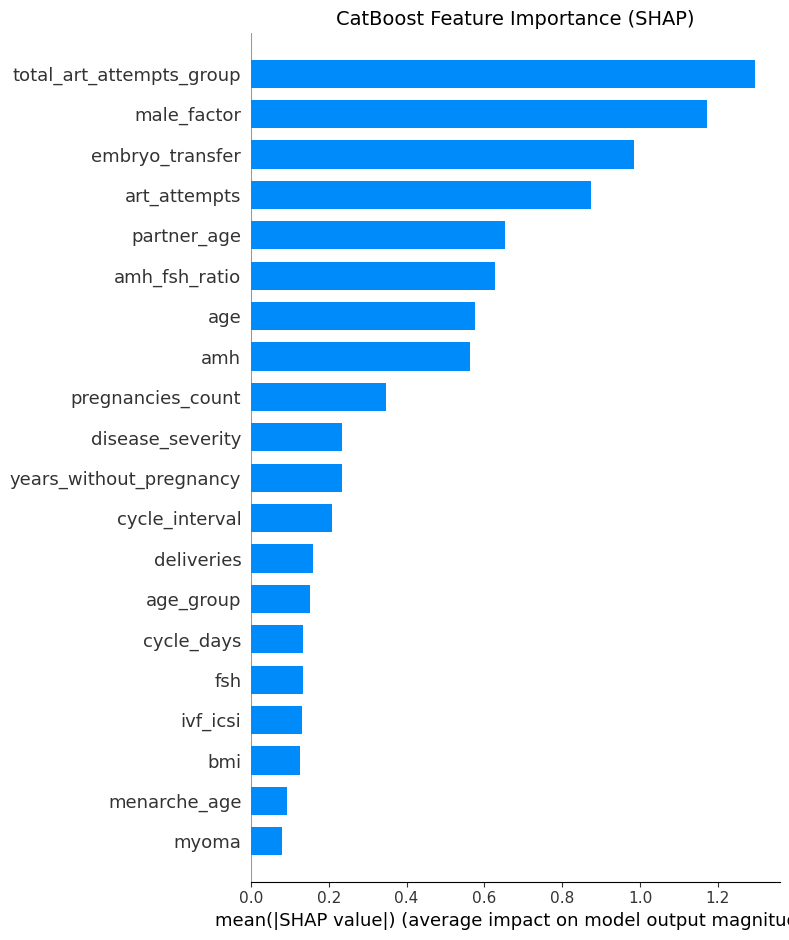

C:\Users\alisa\AppData\Local\Temp\ipykernel_17948\3276492366.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_rg, show=False)


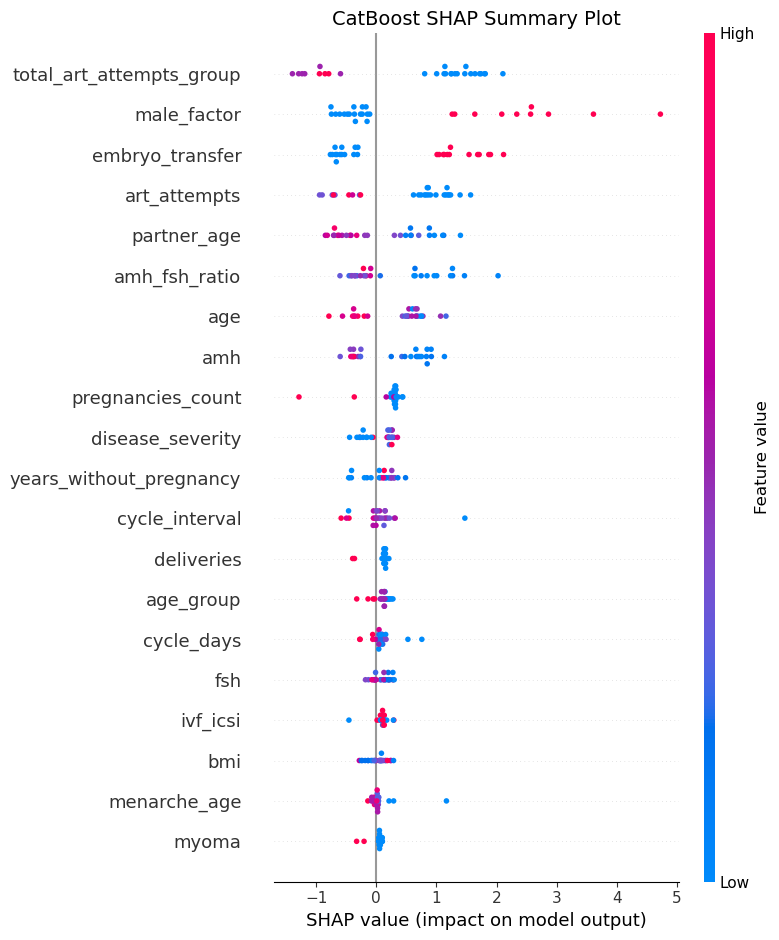

In [17]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(cat_model_final)

shap_values = explainer.shap_values(X_test_cat)

# Summary Plot

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_rg, plot_type="bar", show=False)
plt.title("CatBoost Feature Importance (SHAP)", fontsize=14)
plt.tight_layout()
plt.savefig("shap_catboost_summary_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# Beeswarm plot

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_rg, show=False)
plt.title("CatBoost SHAP Summary Plot", fontsize=14)
plt.tight_layout()
plt.savefig("shap_catboost_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

### MLP

In [18]:
seed = 789

set_seed(seed)

final_mlp = train_mlp_final(
    X_train_val_p,
    pd.concat([y_train, y_val]),
    n_epochs=mlp_cv['cv_best_epoch']
)

best_thr = mlp_cv['cv_threshold']

final_mlp.eval()
with torch.no_grad():
    y_prob = torch.sigmoid(
        final_mlp(torch.tensor(X_test_p, dtype=torch.float32))
    ).numpy().flatten()

y_pred = (y_prob >= best_thr).astype(int)

Размер shap_values: (27, 30)
Размер X_test_p: (27, 30)


C:\Users\alisa\AppData\Local\Temp\ipykernel_17948\3342166520.py:23: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


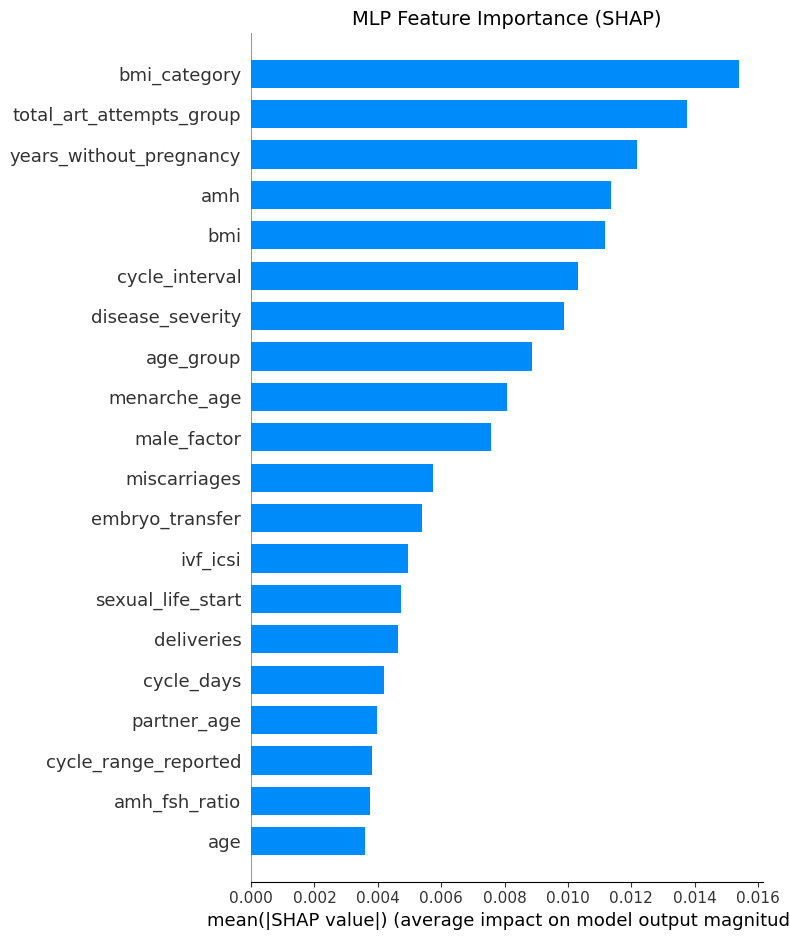

C:\Users\alisa\AppData\Local\Temp\ipykernel_17948\3342166520.py:37: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


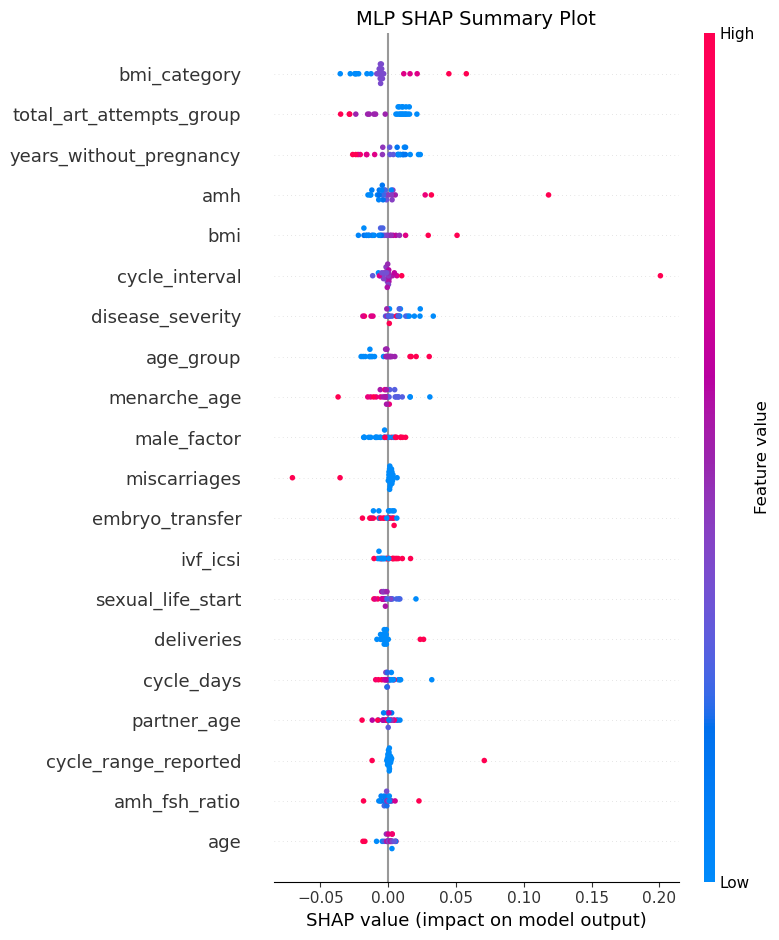

In [19]:
background = torch.tensor(X_train_val_p[:100], dtype=torch.float32)
test_tensor = torch.tensor(X_test_p, dtype=torch.float32)

explainer = shap.DeepExplainer(final_mlp, background)
shap_values = explainer.shap_values(test_tensor)

if isinstance(shap_values, list):
    shap_values = shap_values[0]                    
if len(shap_values.shape) == 3:
    shap_values = shap_values.squeeze(axis=-1)

print("Размер shap_values:", shap_values.shape)
print("Размер X_test_p:", X_test_p.shape)

# Проверка
assert shap_values.shape[1] == X_test_p.shape[1], "Размеры не совпадают!"

# Summary plot
feature_names = preprocessor.get_feature_names_out()
clean_names = [name.split('__')[-1] for name in feature_names]

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_test_p, 
    feature_names=clean_names,
    plot_type="bar", 
    show=False
)
plt.title("MLP Feature Importance (SHAP)", fontsize=14)
plt.tight_layout()
plt.savefig("shap_mlp_summary_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# Beeswarm plot
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values, 
    X_test_p, 
    feature_names=clean_names,
    show=False
)
plt.title("MLP SHAP Summary Plot", fontsize=14)
plt.tight_layout()
plt.savefig("shap_mlp_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

### Logistic Regression

In [20]:
probs = logreg.predict_proba(X_test_p)[:, 1]
pred  = (probs >= 0.5).astype(int)                   

print("=== Поиск клинически интересных пациентов ===")
print(f"Всего в тесте: {len(y_test)} пациентов\n")

# 1. Самая высокая вероятность беременности (успешный случай)
idx_high = probs.argmax()
print(f"1. Высокая вероятность (успех):")
print(f"   Индекс в тесте: {idx_high}")
print(f"   Истинный исход: {y_test.iloc[idx_high]} | Предсказанная вероятность: {probs[idx_high]:.4f}")

# 2. Самая низкая вероятность (неудача)
idx_low = probs.argmin()
print(f"\n2. Низкая вероятность (неудача):")
print(f"   Индекс в тесте: {idx_low}")
print(f"   Истинный исход: {y_test.iloc[idx_low]} | Предсказанная вероятность: {probs[idx_low]:.4f}")

# 3. Пограничный случай (ближе всего к порогу 0.5)
borderline_dist = np.abs(probs - 0.5)
idx_border = borderline_dist.argmin()
print(f"\n3. Пограничный случай (≈ 0.5):")
print(f"   Индекс в тесте: {idx_border}")
print(f"   Истинный исход: {y_test.iloc[idx_border]} | Предсказанная вероятность: {probs[idx_border]:.4f}")

=== Поиск клинически интересных пациентов ===
Всего в тесте: 27 пациентов

1. Высокая вероятность (успех):
   Индекс в тесте: 10
   Истинный исход: 1 | Предсказанная вероятность: 1.0000

2. Низкая вероятность (неудача):
   Индекс в тесте: 22
   Истинный исход: 0 | Предсказанная вероятность: 0.0118

3. Пограничный случай (≈ 0.5):
   Индекс в тесте: 17
   Истинный исход: 1 | Предсказанная вероятность: 0.5635


Размер shap_values: (27, 30)
Размер X_test_p: (27, 30)


C:\Users\alisa\AppData\Local\Temp\ipykernel_17948\435612675.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_p, feature_names=clean_names,


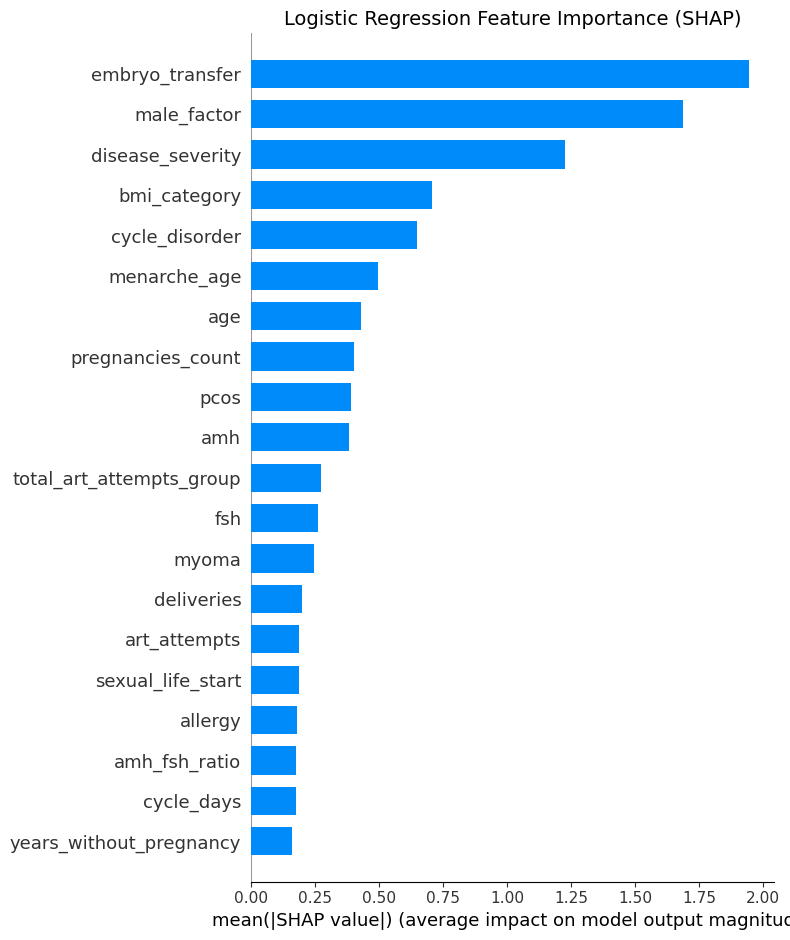

C:\Users\alisa\AppData\Local\Temp\ipykernel_17948\435612675.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_p, feature_names=clean_names, show=False)


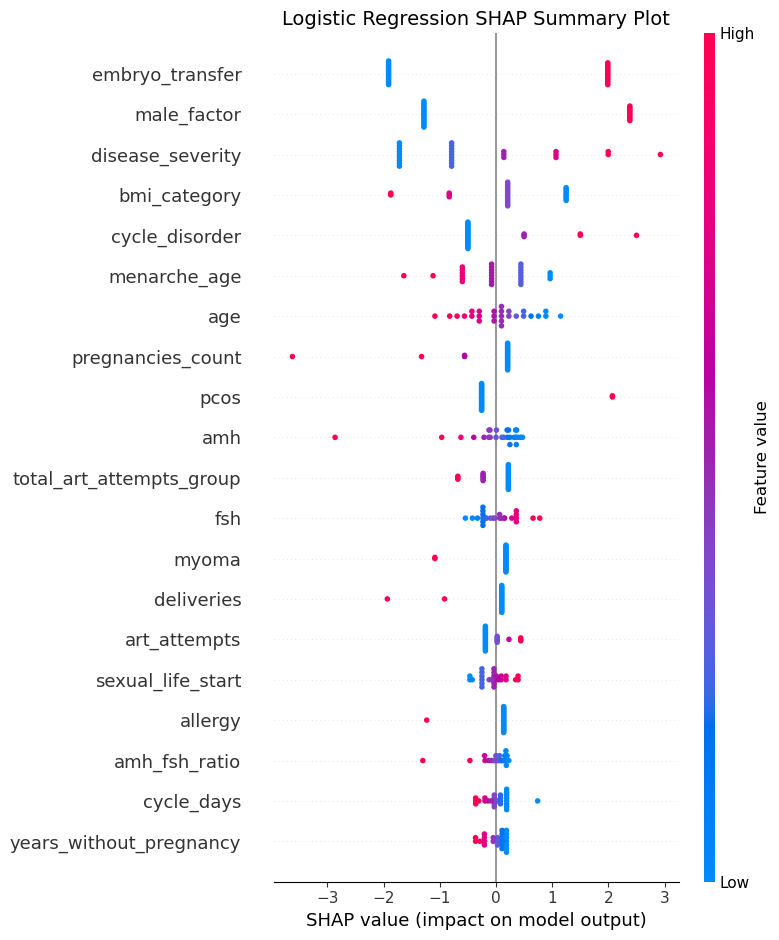

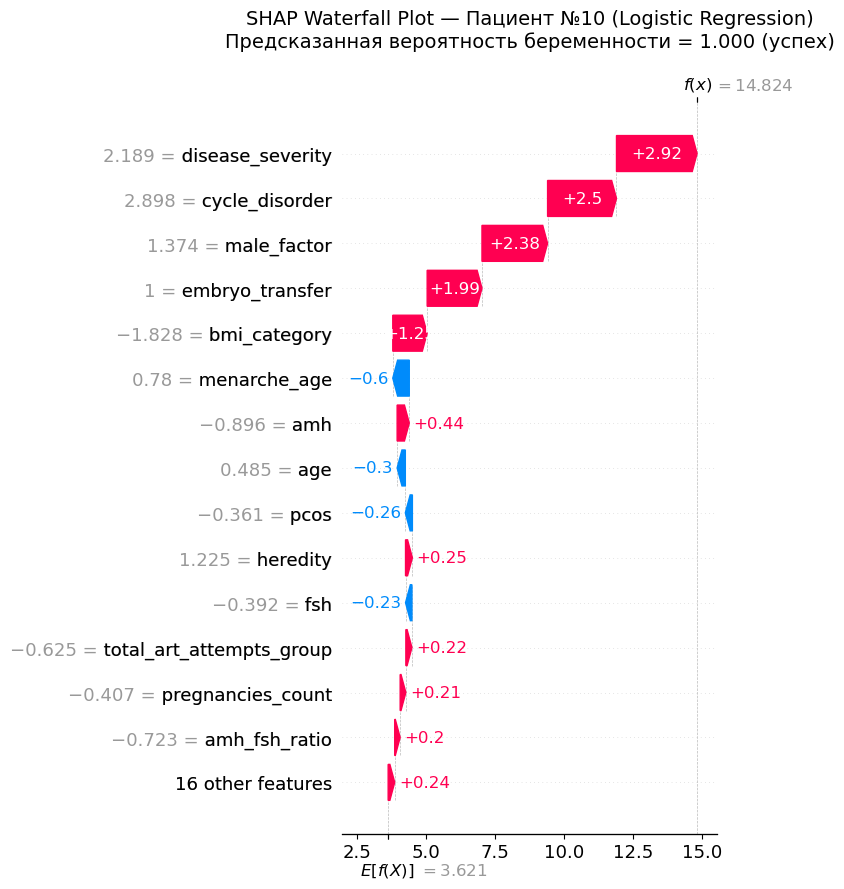

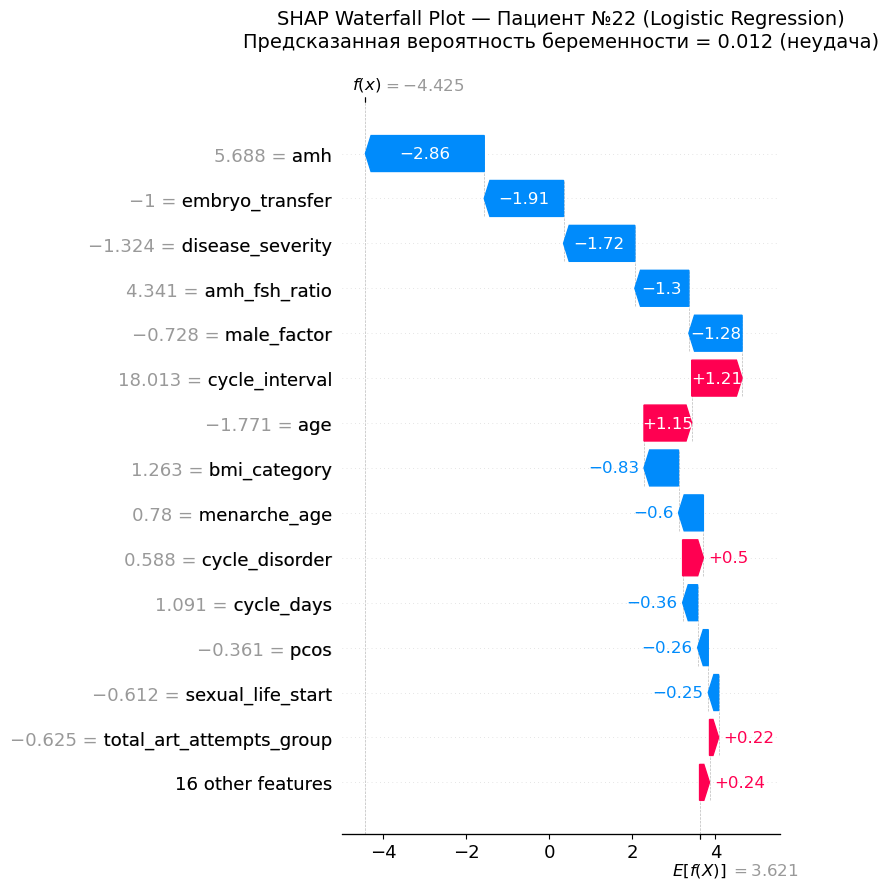

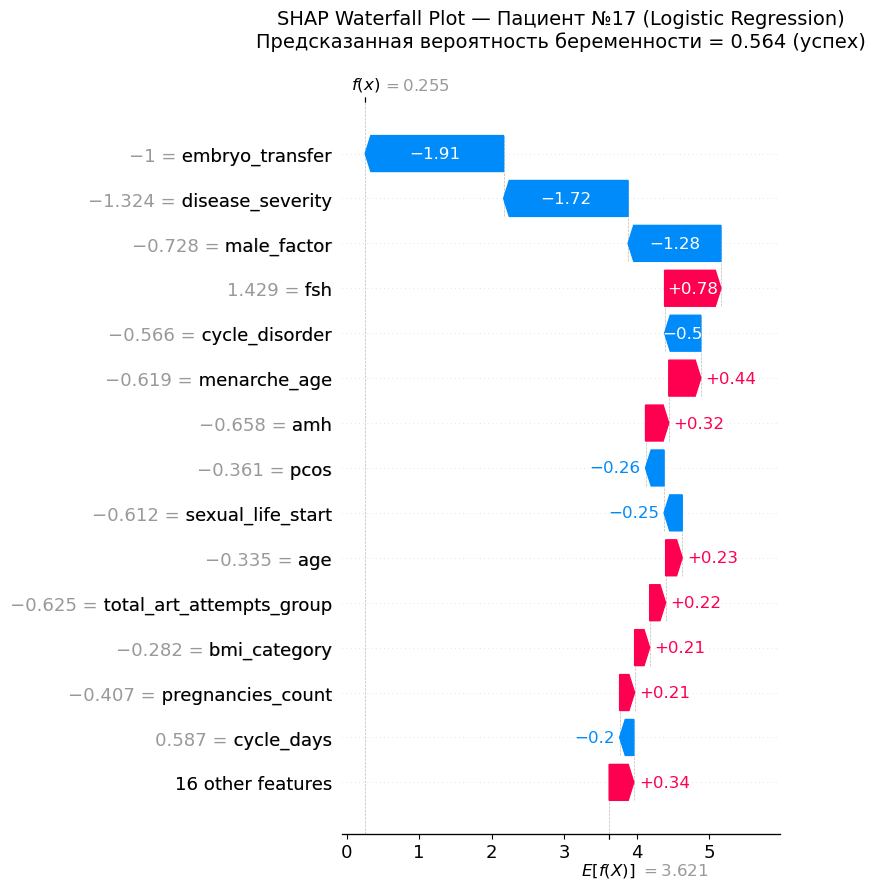

In [21]:
explainer = shap.LinearExplainer(logreg, X_train_val_p)
shap_values = explainer.shap_values(X_test_p)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

print("Размер shap_values:", shap_values.shape)
print("Размер X_test_p:", X_test_p.shape)

# Чистые имена признаков (убираем num__ и cat__)
feature_names = preprocessor.get_feature_names_out()
clean_names = [name.split('__')[-1] for name in feature_names]

# Summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_p, feature_names=clean_names, 
                  plot_type="bar", show=False)
plt.title("Logistic Regression Feature Importance (SHAP)", fontsize=14)
plt.tight_layout()
plt.savefig("shap_lr_summary_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# Beeswarm plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_p, feature_names=clean_names, show=False)
plt.title("Logistic Regression SHAP Summary Plot", fontsize=14)
plt.tight_layout()
plt.savefig("shap_lr_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

# Waterfall plot для одного пациента
for patient_idx in [idx_high, idx_low, idx_border]:
    
    exp = shap.Explanation(
        values=shap_values[patient_idx],
        base_values=explainer.expected_value,          
        data=X_test_p[patient_idx],                     
        feature_names=clean_names
    )

    plt.figure(figsize=(12, 8))
    shap.plots.waterfall(exp, max_display=15, show=False)
    
    prob = logreg.predict_proba(X_test_p[[patient_idx]])[0][1]
    plt.title(f"SHAP Waterfall Plot — Пациент №{patient_idx} (Logistic Regression)\n"
              f"Предсказанная вероятность беременности = {prob:.3f} "
              f"({'успех' if prob > 0.5 else 'неудача'})",
              fontsize=14, pad=20)
    
    plt.tight_layout()
    plt.savefig(f"shap_lr_waterfall_patient_{patient_idx}.png", 
                dpi=300, bbox_inches="tight")
    plt.show()

### Random Forest

Исходная форма: (27, 30)
После выбора класса 1: (27, 30)


C:\Users\alisa\AppData\Local\Temp\ipykernel_17948\2841920760.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


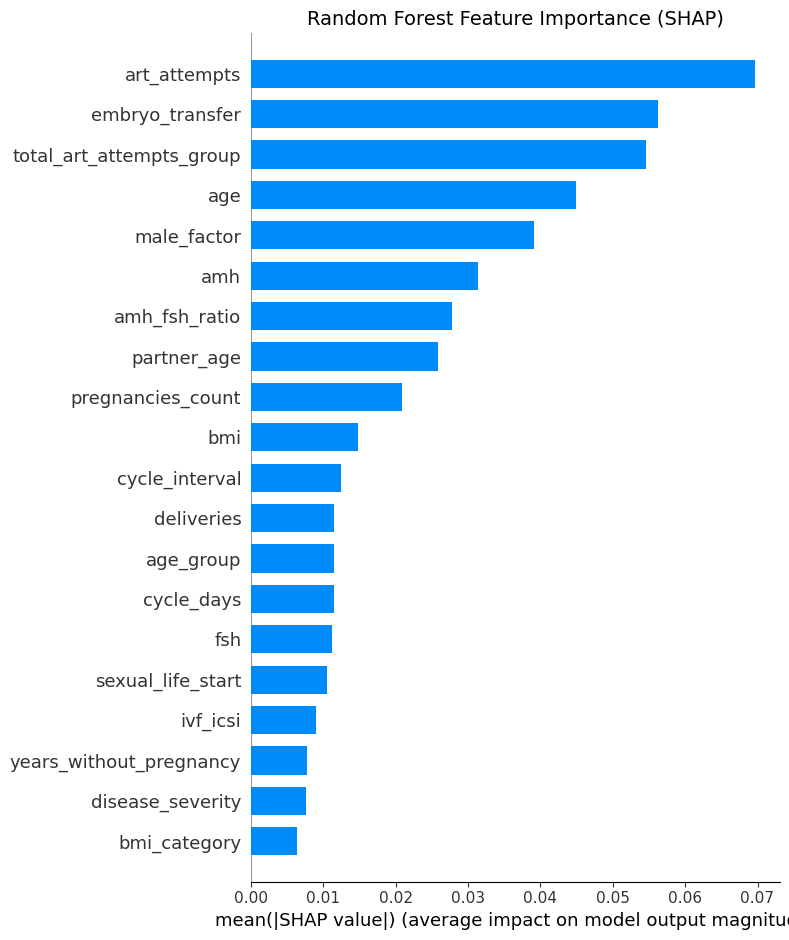

C:\Users\alisa\AppData\Local\Temp\ipykernel_17948\2841920760.py:33: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


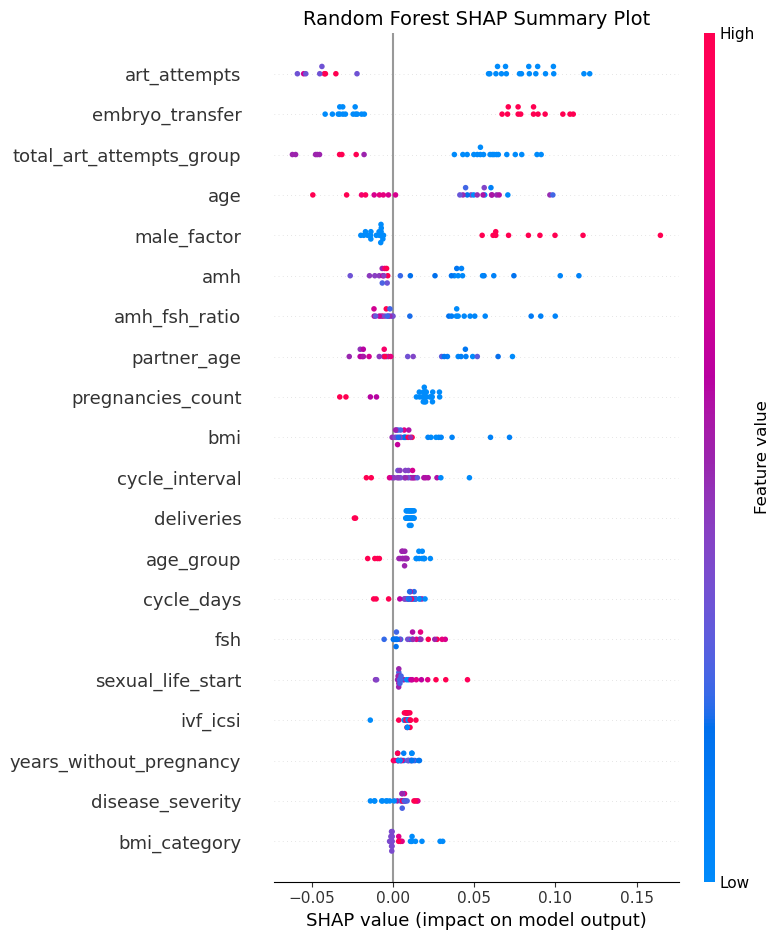

In [22]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_p)

if len(np.array(shap_values).shape) == 3:
    shap_values = np.array(shap_values)[:, :, 1]
elif isinstance(shap_values, list):
    shap_values = shap_values[1]

print("Исходная форма:", shap_values.shape)

print("После выбора класса 1:", shap_values.shape)

# Чистые имена признаков
clean_names = [name.split('__')[-1] for name in preprocessor.get_feature_names_out()]

# Summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_test_p, 
    feature_names=clean_names,
    plot_type="bar",
    show=False,
    max_display=20      
)
plt.title("Random Forest Feature Importance (SHAP)", fontsize=14)
plt.tight_layout()
plt.savefig("shap_rf_summary_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# Beeswarm plot
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values, 
    X_test_p, 
    feature_names=clean_names,
    show=False,
    max_display=20
)
plt.title("Random Forest SHAP Summary Plot", fontsize=14)
plt.tight_layout()
plt.show()


# Confusion Matrix + клинических метрик

### Logistic Regression

LOGISTIC REGRESSION - Confusion Matrix и клинические метрики

Confusion Matrix:
[[ 1  2]
 [ 3 21]]

Клинические метрики:
  TN                       : 1
  FP                       : 2
  FN                       : 3
  TP                       : 21
  Accuracy                 : 0.8148
  Sensitivity              : 0.875
  Specificity              : 0.3333
  Precision                : 0.913
  NPV                      : 0.25
  F1-score                 : 0.8936
  AUC-ROC                  : 0.8056


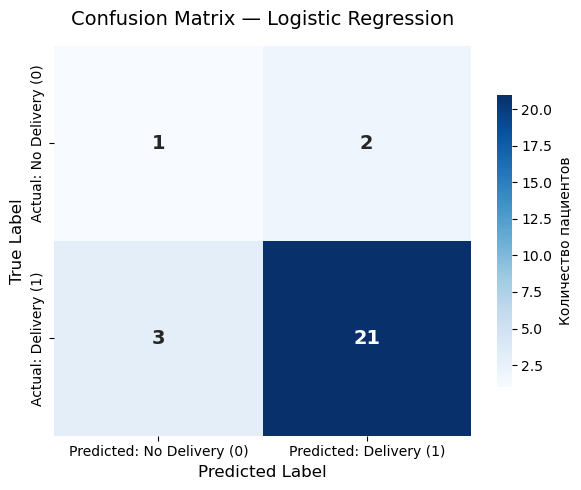

In [23]:
import seaborn as sns

y_prob_lr = logreg.predict_proba(X_test_p)[:, 1]
y_pred_lr = (y_prob_lr >= best_thr_lr).astype(int)

cm_lr, metrics_lr = calculate_clinical_metrics(
    y_true=y_test, 
    y_pred=y_pred_lr, 
    y_prob=y_prob_lr
)

print("=" * 60)
print("LOGISTIC REGRESSION - Confusion Matrix и клинические метрики")
print("=" * 60)
print("\nConfusion Matrix:")
print(cm_lr)
print("\nКлинические метрики:")
for key, value in metrics_lr.items():
    print(f"  {key:25}: {value}")

# Визуализация

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lr, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=True,                                     
    cbar_kws={"shrink": 0.75, "label": "Количество пациентов"},
    xticklabels=['Predicted: No Delivery (0)', 'Predicted: Delivery (1)'],
    yticklabels=['Actual: No Delivery (0)', 'Actual: Delivery (1)'],
    annot_kws={"size": 14, "weight": "bold"}
)
plt.title("Confusion Matrix — Logistic Regression", fontsize=14, pad=15)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix_logreg.png", dpi=300, bbox_inches="tight")
plt.show()

# Сохранение

metrics_df_lr = pd.DataFrame([metrics_lr]).T
metrics_df_lr.columns = ['Logistic Regression']
metrics_df_lr.index.name = 'Metric'

### MLP

MLP (PyTorch) - Confusion Matrix и клинические метрики

Confusion Matrix:
[[ 0  3]
 [ 0 24]]

Клинические метрики:
  TN                       : 0
  FP                       : 3
  FN                       : 0
  TP                       : 24
  Accuracy                 : 0.8889
  Sensitivity              : 1.0
  Specificity              : 0.0
  Precision                : 0.8889
  NPV                      : 0
  F1-score                 : 0.9412
  AUC-ROC                  : 0.4583


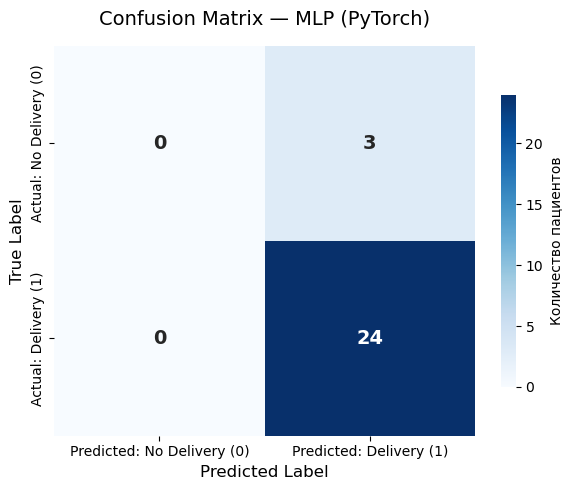

In [24]:
# Переводим в тензор
X_test_tensor = torch.tensor(X_test_p, dtype=torch.float32)

cm_mlp, metrics_mlp = calculate_clinical_metrics(
    y_true=y_test, 
    y_pred=y_pred, 
    y_prob=y_prob
)

print("=" * 60)
print("MLP (PyTorch) - Confusion Matrix и клинические метрики")
print("=" * 60)
print("\nConfusion Matrix:")
print(cm_mlp)
print("\nКлинические метрики:")
for key, value in metrics_mlp.items():
    print(f"  {key:25}: {value}")

# Визуализация

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_mlp, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=True,                                    
    cbar_kws={"shrink": 0.75, "label": "Количество пациентов"},
    xticklabels=['Predicted: No Delivery (0)', 'Predicted: Delivery (1)'],
    yticklabels=['Actual: No Delivery (0)', 'Actual: Delivery (1)'],
    annot_kws={"size": 14, "weight": "bold"}
)
plt.title("Confusion Matrix — MLP (PyTorch)", fontsize=14, pad=15)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix_mlp.png", dpi=300, bbox_inches="tight")
plt.show()

# Сохранение

metrics_df_mlp = pd.DataFrame([metrics_mlp]).T
metrics_df_mlp.columns = ['MLP']
metrics_df_mlp.index.name = 'Metric'

### Random Forest

RANDOM FOREST - Confusion Matrix и клинические метрики

Confusion Matrix:
[[ 1  2]
 [ 7 17]]

Клинические метрики:
  TN                       : 1
  FP                       : 2
  FN                       : 7
  TP                       : 17
  Accuracy                 : 0.6667
  Sensitivity              : 0.7083
  Specificity              : 0.3333
  Precision                : 0.8947
  NPV                      : 0.125
  F1-score                 : 0.7907
  AUC-ROC                  : 0.7083


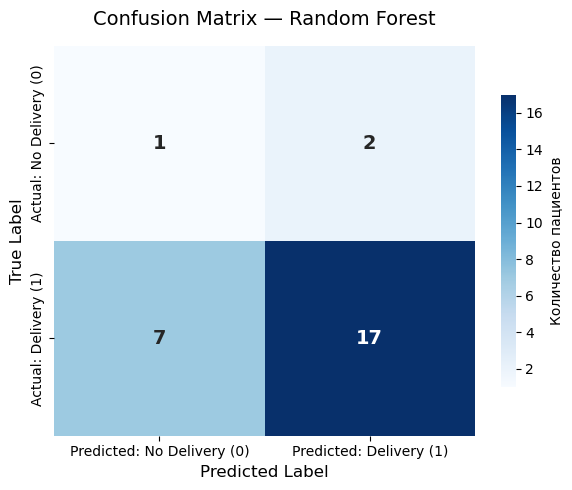

In [25]:
y_prob_rf = rf.predict_proba(X_test_p)[:, 1]
y_pred_rf = (y_prob_rf >= best_thr_rf).astype(int)

cm_rf, metrics_rf = calculate_clinical_metrics(
    y_true=y_test, 
    y_pred=y_pred_rf, 
    y_prob=y_prob_rf
)

print("=" * 60)
print("RANDOM FOREST - Confusion Matrix и клинические метрики")
print("=" * 60)
print("\nConfusion Matrix:")
print(cm_rf)
print("\nКлинические метрики:")
for key, value in metrics_rf.items():
    print(f"  {key:25}: {value}")

# Визуализация

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=True,                                    
    cbar_kws={"shrink": 0.75, "label": "Количество пациентов"},
    xticklabels=['Predicted: No Delivery (0)', 'Predicted: Delivery (1)'],
    yticklabels=['Actual: No Delivery (0)', 'Actual: Delivery (1)'],
    annot_kws={"size": 14, "weight": "bold"}
)
plt.title("Confusion Matrix — Random Forest", fontsize=14, pad=15)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix_rf.png", dpi=300, bbox_inches="tight")
plt.show()

# Сохранение

metrics_df_rf = pd.DataFrame([metrics_rf]).T
metrics_df_rf.columns = ['Random Forest']
metrics_df_rf.index.name = 'Metric'

### CatBoost

CATBOOST — Confusion Matrix и клинические метрики

Confusion Matrix:
[[ 0  3]
 [ 4 20]]

Клинические метрики:
  TN                       : 0
  FP                       : 3
  FN                       : 4
  TP                       : 20
  Accuracy                 : 0.7407
  Sensitivity              : 0.8333
  Specificity              : 0.0
  Precision                : 0.8696
  NPV                      : 0.0
  F1-score                 : 0.8511
  AUC-ROC                  : 0.7222


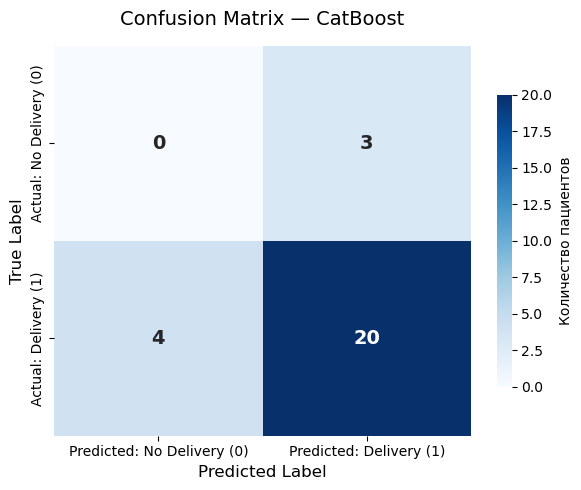

In [26]:
cm_cat, metrics_cat = calculate_clinical_metrics(y_test, test_pred_cat, test_prob_cat)

print("=" * 70)
print("CATBOOST — Confusion Matrix и клинические метрики")
print("=" * 70)
print("\nConfusion Matrix:")
print(cm_cat)
print("\nКлинические метрики:")
for key, value in metrics_cat.items():
    print(f"  {key:25}: {value}")

# Визуализация

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_cat, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=True,                                    
    cbar_kws={"shrink": 0.75, "label": "Количество пациентов"},
    xticklabels=['Predicted: No Delivery (0)', 'Predicted: Delivery (1)'],
    yticklabels=['Actual: No Delivery (0)', 'Actual: Delivery (1)'],
    annot_kws={"size": 14, "weight": "bold"}
)
plt.title("Confusion Matrix — CatBoost", fontsize=14, pad=15)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix_catboost.png", dpi=300, bbox_inches="tight")
plt.show()

# Сохранение

metrics_df_cat = pd.DataFrame([metrics_cat]).T
metrics_df_cat.columns = ['CatBoost']
metrics_df_cat.index.name = 'Metric'

# ROC curves

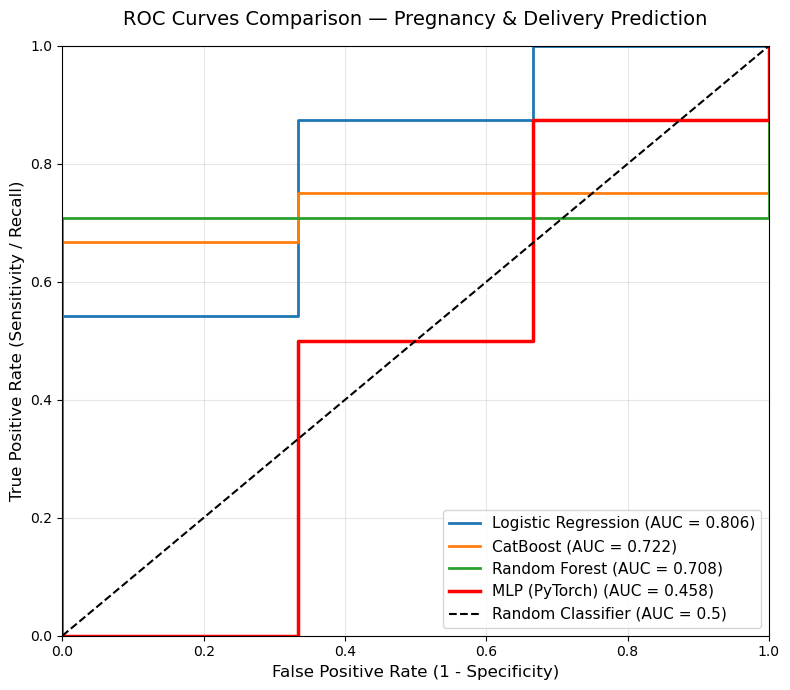


AUC-ROC на тестовом множестве:
  Logistic Regression : 0.8056
  CatBoost            : 0.7222
  Random Forest       : 0.7083
  MLP (PyTorch)       : 0.4583


In [27]:
from sklearn.metrics import roc_curve, roc_auc_score

# Считаем ROC-кривые и AUC

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

fpr_cat, tpr_cat, _ = roc_curve(y_test, test_prob_cat)
auc_cat = roc_auc_score(y_test, test_prob_cat)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_prob)
auc_mlp = roc_auc_score(y_test, y_prob)

# График

plt.figure(figsize=(8, 7))

plt.plot(fpr_lr,  tpr_lr,  label=f'Logistic Regression (AUC = {auc_lr:.3f})', linewidth=2)
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost (AUC = {auc_cat:.3f})', linewidth=2)
plt.plot(fpr_rf,  tpr_rf,  label=f'Random Forest (AUC = {auc_rf:.3f})', linewidth=2)
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP (PyTorch) (AUC = {auc_mlp:.3f})', linewidth=2.5, color='red')

# Диагональ случайного классификатора
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)', linewidth=1.5)

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('ROC Curves Comparison — Pregnancy & Delivery Prediction', fontsize=14, pad=15)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])

plt.tight_layout()
plt.show()

print(f"\nAUC-ROC на тестовом множестве:")
print(f"  Logistic Regression : {auc_lr:.4f}")
print(f"  CatBoost            : {auc_cat:.4f}")
print(f"  Random Forest       : {auc_rf:.4f}")
print(f"  MLP (PyTorch)       : {auc_mlp:.4f}")